# Jaw Keypoint Prediction

Set `VIDEO_PATH` and `OUTPUT_DIR` below. Uses the **shared** checkpoint at `../Training/checkpoints/best_model.pt`.

Writes dataset-style CSVs to `OUTPUT_DIR`:
- `jaw_tip.csv` — `frame,x,y`
- `jaw_base.csv` — `frame,x,y` (jaw line / base keypoint)

Coordinates are in the source video's pixel space. Frame numbers are 0-based video frame indices.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path("utils.py").resolve().parent))
from utils import run_inference_on_video, default_checkpoint_path

# ── Configuration ──────────────────────────────────────────────────────────
VIDEO_PATH = "/mnt/c/Users/wanglab/Desktop/Ina/IRt_BiPoles/IRt_01/2025_0425/IRt_BiPoles_01_2025_0425_side_view.mp4"
OUTPUT_DIR = "/mnt/c/Users/wanglab/Desktop/Ina/IRt_BiPoles/IRt_01/2025_0425/predictions"
BATCH_SIZE = 32

CHECKPOINT = default_checkpoint_path()
print(f"Checkpoint: {CHECKPOINT}")

Checkpoint: ../Training/checkpoints/IRt_BiPoles/best_model.pt


In [2]:
df, tip_csv, base_csv = run_inference_on_video(
    video_path=VIDEO_PATH,
    output_dir=OUTPUT_DIR,
    checkpoint_path=CHECKPOINT,
    batch_size=BATCH_SIZE,
)
df.head()

Loaded IRt_BiPoles model from ../Training/checkpoints/IRt_BiPoles/best_model.pt
Video: /mnt/c/Users/wanglab/Desktop/Ina/IRt_BiPoles/IRt_01/2025_0425/IRt_BiPoles_01_2025_0425_side_view.mp4
Frames: 87,400
Checkpoint: ../Training/checkpoints/IRt_BiPoles/best_model.pt


Video chunks: 100%|██████████| 171/171 [34:40<00:00, 12.16s/chunk]


Wrote /mnt/c/Users/wanglab/Desktop/Ina/IRt_BiPoles/IRt_01/2025_0425/predictions/jaw_tip.csv
Wrote /mnt/c/Users/wanglab/Desktop/Ina/IRt_BiPoles/IRt_01/2025_0425/predictions/jaw_base.csv


,frame,tip_x,tip_y,line_x,line_y
0,0,338.760834,205.670700,367.850494,215.878265
1,1,338.680725,212.042389,375.697083,218.298828
2,2,334.063202,204.996643,380.103882,217.347290
3,3,337.281616,205.011276,391.633240,218.209747
4,4,332.934814,201.358032,390.625610,216.345505


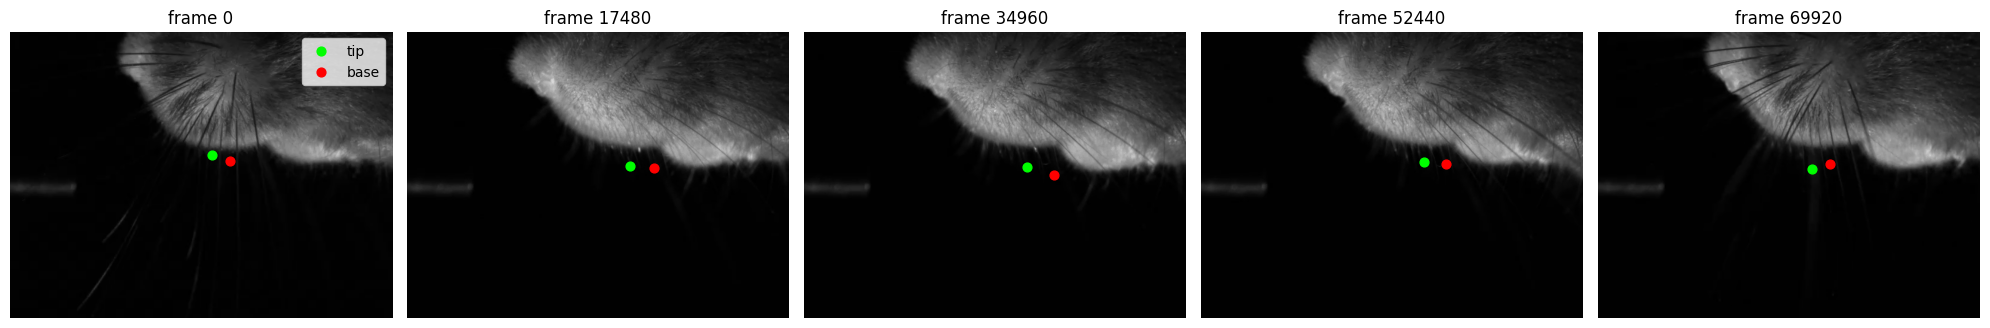

In [3]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd

# Overlay predictions on a few sample frames from the video
cap = cv2.VideoCapture(VIDEO_PATH)
sample_frames = df["frame"].iloc[:: max(1, len(df) // 5)][:5].astype(int)

fig, axes = plt.subplots(1, len(sample_frames), figsize=(4 * len(sample_frames), 4))
if len(sample_frames) == 1:
    axes = [axes]

tip_df = pd.read_csv(tip_csv)
base_df = pd.read_csv(base_csv)

for ax, fr in zip(axes, sample_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fr))
    ret, bgr = cap.read()
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    tip = tip_df.loc[tip_df["frame"] == fr].iloc[0]
    base = base_df.loc[base_df["frame"] == fr].iloc[0]
    ax.scatter(tip["x"], tip["y"], c="lime", s=40, label="tip")
    ax.scatter(base["x"], base["y"], c="red", s=40, label="base")
    ax.set_title(f"frame {fr}")
    ax.axis("off")

cap.release()
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()